<a href="https://colab.research.google.com/github/Clovis4566/TECH-TALENT-ACCELERATOR/blob/main/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve:Les LLM résolvent principalement des problèmes liés au traitement du langage naturel (NLP) :Génération de texte : Rédaction d'e-mails, de rapports, d'articles ou de scénarios.Synthèse et extraction : Résumé automatique de longs documents pour en extraire les informations clés.Traduction : Traduction fluide et contextuelle entre différentes langues.Assistance et Service Client : Réponses aux questions sous forme de chatbots (ex: ChatGPT, Gemini).Programmation informatique : Écriture, explication et correction (débogage) de codes dans divers langages (Python, JavaScript, etc.).Raisonnement et analyse : Analyse des sentiments dans les avis clients ou résolution de problèmes logiques et mathématiques.


### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 8.8 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [12]:
# Install necessary libraries
!pip install transformers matplotlib --quiet

# Import required libraries
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.

Original Text: Le deep learning est fascinant !
Tokens: ['Le', 'Ġdeep', 'Ġlearning', 'Ġest', 'Ġfasc', 'inant', 'Ġ!']
Token IDs: [3123, 2769, 4673, 1556, 7751, 42483, 5145]


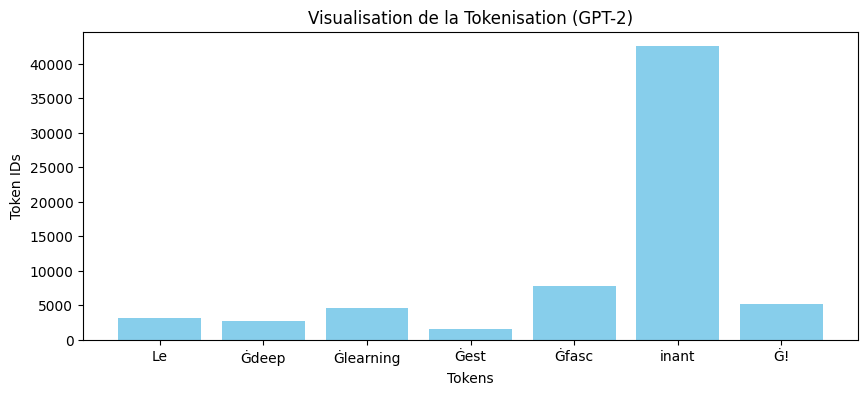

In [15]:
# 2. Loading a pretrained model and tokenizer
# `model_name` is set to "gpt2" to align with the notebook's goal of using a causal language model (GPT-2)
# and the existing kernel state `model_name = 'gpt2'`.
# The original descriptive text after `model_name` was causing a SyntaxError.
model_name = "gpt2" # is used here for demonstration; can be replaced with models like "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

# The following section was a redundant or older block for loading model/tokenizer
# and defining text for tokenization. Consolidating the `text` definition
# and tokenization/plotting with the main flow.

text = "Le deep learning est fascinant !" # Example text for tokenization

# 2. Tokenize input text
# On convertit le texte en tokens (mots/sous-mots)
tokens = tokenizer.tokenize(text)

# On convertit ces tokens en identifiants numériques (IDs)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

# 3. Visualizing the tokenization process
plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")

# Remplissage des labels manquants
plt.xlabel("Tokens")
plt.ylabel("Token IDs")
plt.title("Visualisation de la Tokenisation (GPT-2)") # Changed title to reflect GPT-2

plt.show()

## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


Original Text: Hello, Colab! This is a tokenization example.
Tokens: ['Hello', ',', 'ĠCol', 'ab', '!', 'ĠThis', 'Ġis', 'Ġa', 'Ġtoken', 'ization', 'Ġexample', '.']
Token IDs: [15496, 11, 1623, 397, 0, 770, 318, 257, 11241, 1634, 1672, 13]


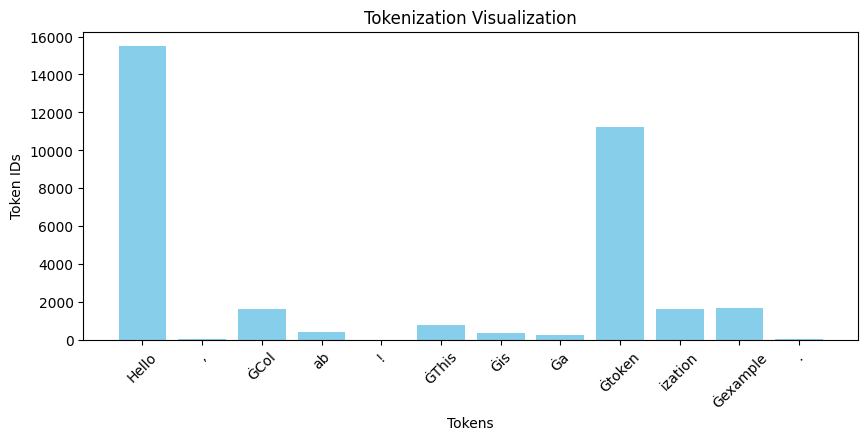

In [17]:
text = "Hello, Colab! This is a tokenization example."  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Tokenization Visualization"    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [20]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
# Iterate over `tokens` and `token_ids`, printing each mapping.
for token, token_id in zip(tokens, token_ids):
    print(f"Token: '{token}', ID: {token_id}")

Token: 'Hello', ID: 15496
Token: ',', ID: 11
Token: 'ĠCol', ID: 1623
Token: 'ab', ID: 397
Token: '!', ID: 0
Token: 'ĠThis', ID: 770
Token: 'Ġis', ID: 318
Token: 'Ġa', ID: 257
Token: 'Ġtoken', ID: 11241
Token: 'ization', ID: 1634
Token: 'Ġexample', ID: 1672
Token: '.', ID: 13


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.IL REMPLACE L4ESPACE VIDE PAR UN VRAI CARACTERE


## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [22]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "Once upon a time, in a land far, far away"  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'top_p', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: Once upon a time, in a land far, far away
Generated Output: Once upon a time, in a land far, far away from the stars, the wind blew a white wind, and the earth trembled, and the waves, the winds, were as heavy and loud as they were strong, and the stars were as strong as the sun. There was a heaven, and there was a sea, and there was a land


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?:
1. La Temperature : Le curseur du "Style" et de la "Créativité"C'est le paramètre principal pour changer radicalement le ton, la structure et l'originalité de la continuation.Temperature basse (ex: 0.2 ou 0.0) ➡️ Le Robot PrécisLe modèle devient ultra-déterministe. Il choisit systématiquement les mots les plus probables et logiques.Style : Factuel, répétitif, académique, prévisible. Excellent pour le code informatique ou les analyses de données.Temperature haute (ex: 0.8 ou 1.2) ➡️ L'Artiste ImprévisibleLe modèle prend des risques en choisissant des mots moins évidents mais contextuellement valides.Style : Créatif, varié, poétique, parfois surprenant ou légèrement décousu. Idéal pour le brainstorming ou l'écriture de fiction.2. Max Tokens : Le curseur de la "Quantité"Ce paramètre est une limite physique de longueur (le nombre maximal de mots/morceaux de mots à générer). Il n'a aucun impact sur le style ou la structure des phrases en soi.Si la valeur est trop basse (ex: 20 tokens) : Le modèle sera coupé en plein milieu de sa phrase, ce qui donne une impression de texte incomplet, peu importe que le style soit créatif ou non.Si la valeur est haute (ex: 500 tokens) : Le modèle a l'espace nécessaire pour développer un raisonnement complet, mais c'est la temperature qui décidera si ce long texte sera ennuyeux ou original.📊 En résuméParamètreCe qu'il contrôleImpact sur le StyleTemperatureLe niveau de risque / hasard dans le choix des motsMaximum (gère la créativité, l'originalité et la structure du ton).Max TokensLa longueur maximale du texte généréNul (gère uniquement le volume, pas la manière de s'exprimer).


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)